<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Grace_Drought_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap

In [2]:
import xarray as xr
import numpy as np

In [3]:
!pip install xee
import xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.4 MB/s eta 0:00:00


In [4]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [5]:
map = geemap.Map(basemap = 'TERRAIN')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [6]:
point = map.draw_last_feature.geometry()

In [7]:
roi = (
    ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
    .filterBounds(point)
    .geometry()
    .simplify(1000)
)

In [8]:
map.addLayer(roi, {}, 'ROI')

In [9]:
map

Map(bottom=7233.0, center=[26.64745870265938, 94.47143554687501], controls=(WidgetControl(options=['position',…

In [10]:
grace = (
    ee.ImageCollection("NASA/GRACE/MASS_GRIDS_V04/MASCON_CRI")
    .filterDate('2003', '2025')
    .select('lwe_thickness')
    .map(lambda img: img.clip(roi).copyProperties(img, img.propertyNames()))
)

In [11]:
grace

In [12]:
ds = xr.open_dataset(
    grace,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 1,
    geometry = roi
)

In [13]:
ds = ds.sortby('time') * 1

In [14]:
ds_mean = ds.mean(dim = 'time')
ds_std = ds.std(dim = 'time')

**creates a standardized anomaly index**

In [15]:
gdsi = (ds - ds_mean) / ds_std

In [16]:
gdsi

<xarray.Dataset> Size: 30kB
Dimensions:        (time: 230, lon: 5, lat: 6)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2003-01-31 ... 2024-09-30
  * lon            (lon) float64 40B 88.51 89.51 90.51 91.51 92.51
  * lat            (lat) float64 48B 21.23 22.23 23.23 24.23 25.23 26.23
Data variables:
    lwe_thickness  (time, lon, lat) float32 28kB nan 0.2575 ... 0.9634 nan

**Define classification function**

In [17]:
def classify(val):
  if val >= 2.0: return 1
  elif val >= 1.6: return 2
  elif val >= 1.3: return 3
  elif val >= 0.8: return 4
  elif val >= 0.5: return 5
  elif val >= -0.5: return 6
  elif val >= -0.8: return 7
  elif val >= -1.3: return 8
  elif val >= -1.6: return 9
  elif val >= -2.0: return 10
  else: return 0

**Apply classification to the data**

In [18]:
drought = xr.apply_ufunc(
    np.vectorize(classify),
    gdsi,
    dask = 'allowed'
)


**Replace zeros with NaN**

In [19]:
drought = xr.where((drought == 0), np.nan, drought)

**Aggregate annually**

In [20]:
drought_annual = drought.resample(time = 'Y').median('time')

In [21]:
import matplotlib.pyplot as plt

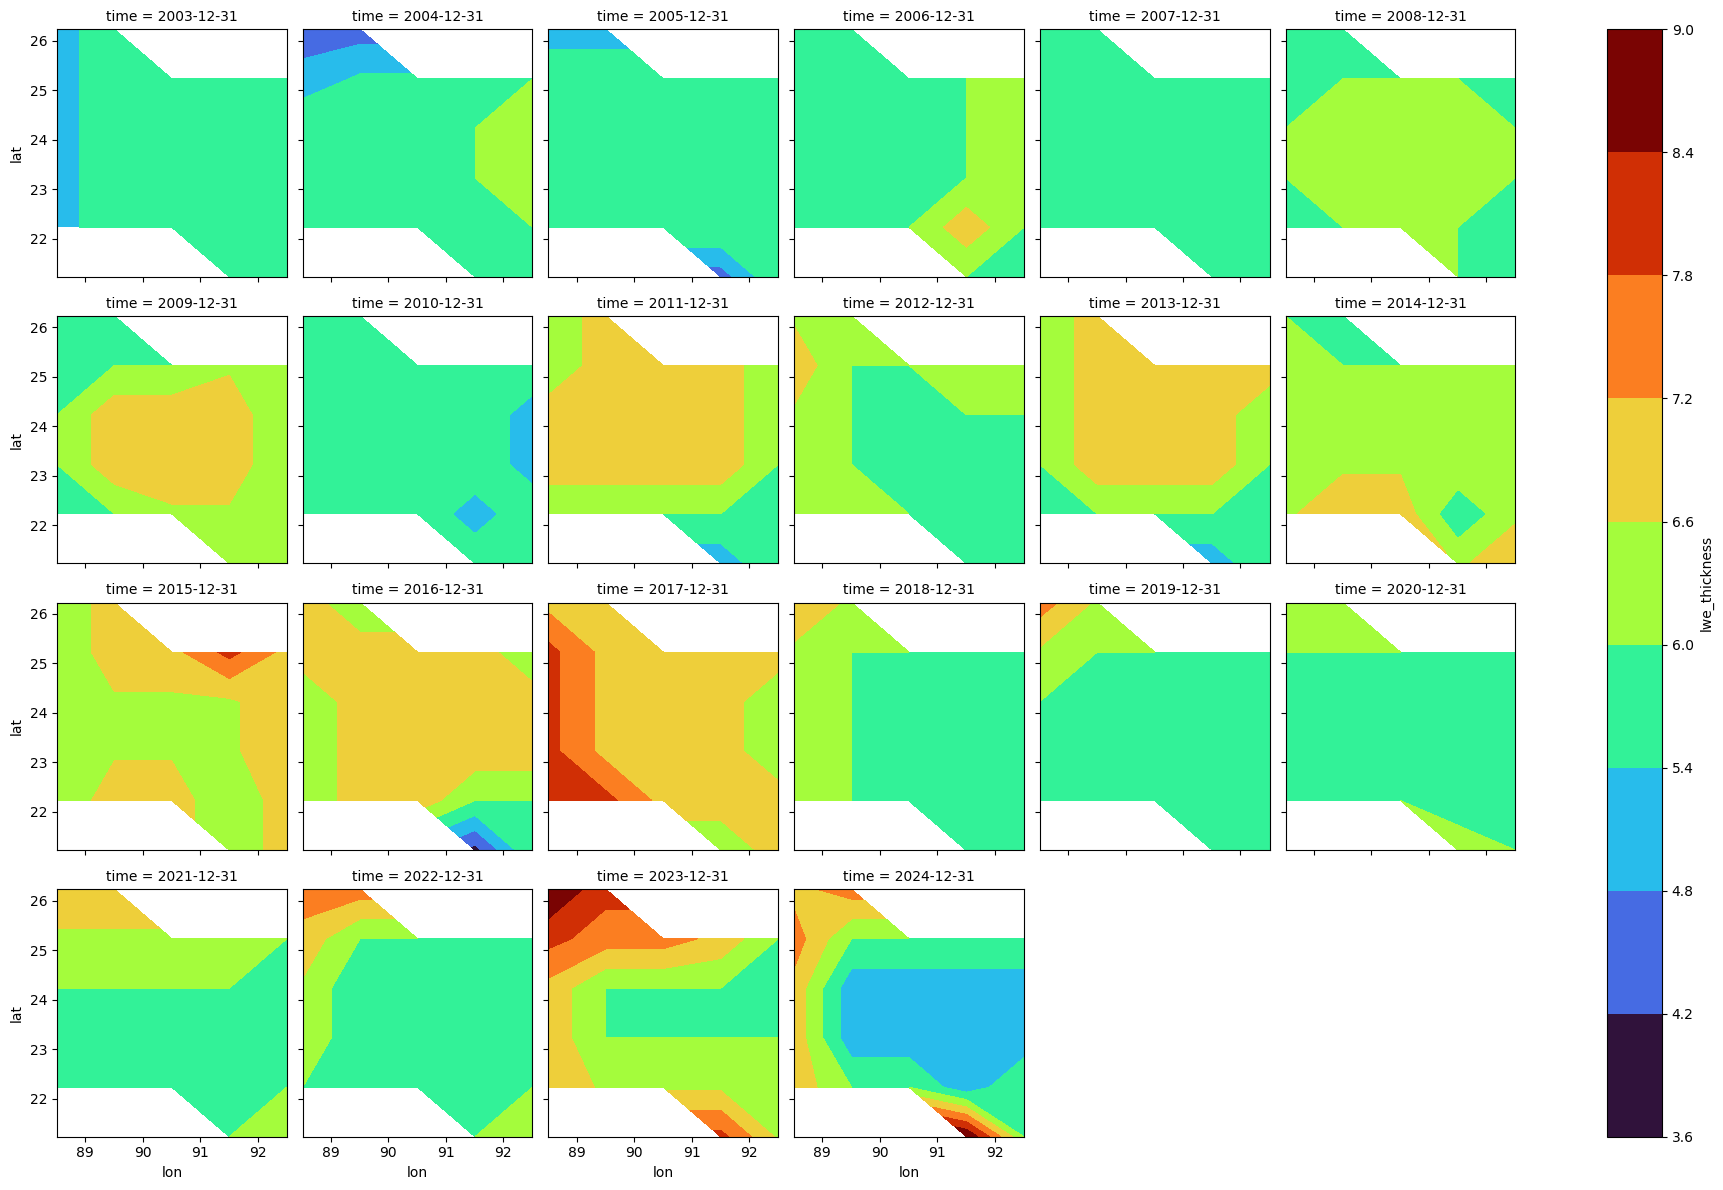

In [25]:
drought_annual.lwe_thickness.plot.contourf(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 6,
    cmap = 'turbo',
    levels = 10
)
